# E13: CellTypist labels

**Started:** February 23, 2026

**Last updated:** February 23, 2026

**Research questions:** Do cell type labels based on CellTypist result in more sensible nearest neighbor pairings?

**Hypothesis:** Yes, because CellTypist labels based on quantitative transformations on the gene expression values, rather than direct human labeling.

**Conclusion:** Yes, CellTypist labels ~90% nearest neighbor match (low-level cell type), Tabula Sapiens is ~80%. T cell sublabel accuracy of ~75% with CellTypist labels.

**Potential Next Steps:** Look into integrating gene information with augmented GW.

In [1]:
from __future__ import annotations
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy as sp
from scipy.spatial.distance import cdist
from scipy import sparse
import ot
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import seaborn as sns
import random
from __future__ import annotations
from typing import Any, Dict, Hashable, Iterable, List, Sequence, Tuple, Union, Optional
from speciesot_helpers import label_uniform_cell_type_row, \
                              top_n_organisms_from_species, \
                              cell_types_with_n_per_organism, \
                              sample_equal_cell_types, \
                              ot_between_organisms, \
                              calc_random_mean_std, \
                              test_train_split_adata, \
                              get_cell_type_from_index, \
                              create_label_to_sample_dicts, \
                              concat_index, \
                              show_cell_type_results, \
                              cell_type_knn_acc, \
                              split_adata_by_celltype_tissue, \
                              match_cells_by_celltype_tissue, \
                              combine_transport_plans, \
                              convert_ensembl_to_gene_symbols, \
                              nearest_neighbor_cell_type, \
                              nn_gene_r2
from speciesot_simulation_helpers import run_ot, \
                                         compute_mapping_acc, \
                                         sublabel_match_rate_from_gw, \
                                         plot_got_best_matches_with_labels, \
                                         gw_seeded, \
                                         plot_first_two_dims
import torch
from pytorch_helpers import fit_mlp
import perturbot
from perturbot.match import get_coupling_egw_labels_ott
import celltypist
from celltypist import models
#from perturbot.predict import train_mlp
%matplotlib inline

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load Tabula Sapiens data

In [2]:
human_dir = 'data/tabula_sapiens/'
human_adatas = top_n_organisms_from_species(human_dir, 2, 'human')
human1_adata = human_adatas[0]
convert_ensembl_to_gene_symbols(human1_adata, species="human", make_unique=True)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
HTTP Request: POST https://mygene.info/v3/query/ "HTTP/1.1 200 OK"
HTTP Request: POST https://mygene.info/v3/qu

In [3]:
human1a, human1b = split_adata_by_celltype_tissue(human1_adata, cell_number=2000, min_per_cell_type=5)

In [7]:
human1_adata.obs['broad_cell_class'].value_counts()

broad_cell_class
t cell                          3006
endothelial cell                1488
epithelial cell of lung         1317
myeloid leukocyte               1197
fibroblast                      1078
intestinal epithelial cell       596
stem cell                        556
granulocyte                      550
contractile cell                 455
hematopoietic cell               414
lymphocyte of b lineage          367
erythroid lineage cell           179
innate lymphoid cell             152
glandular epithelial cell         93
dendritic cell                    59
transitional epithelial cell      43
glial cell                         7
cardiac endothelial cell           2
Name: count, dtype: int64

In [8]:
immune_broad_classes = ['t cell','myeloid leukocyte','granulocyte','hematopoietic cell','lymphocyte of b lineage','erythroid lineage cell','innate lymphoid cell','dendritic cell']

In [42]:
human1_immune = human1_adata[human1_adata.obs['broad_cell_class'].isin(immune_broad_classes)]

In [43]:
human1_immune.layers["counts"] = human1_immune.X.copy()
sc.pp.normalize_total(human1_immune)
sc.pp.log1p(human1_immune)

In [19]:
models.download_models(force_update = True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 60
📂 Storing models in /n/home05/jmprice/.celltypist/data/models
💾 Downloading model [1/60]: Immune_All_Low.pkl
💾 Downloading model [2/60]: Immune_All_High.pkl
💾 Downloading model [3/60]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/60]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/60]: Adult_Human_MTG.pkl
💾 Downloading model [6/60]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/60]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/60]: Adult_Human_Skin.pkl
💾 Downloading model [9/60]: Adult_Human_Vascular.pkl
💾 Downloading model [10/60]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/60]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/60]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/60]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/60]: Adult_cHSPCs_Illumina.pkl
💾 Downloading model [15/60]: Adult_cHSPCs_Ultima.pkl

In [40]:
immune_model = models.Model.load(model = 'Immune_All_Low.pkl')
immune_model.cell_types

array(['Age-associated B cells', 'Alveolar macrophages', 'B cells',
       'CD16+ NK cells', 'CD16- NK cells', 'CD8a/a', 'CD8a/b(entry)',
       'CMP', 'CRTAM+ gamma-delta T cells', 'Classical monocytes',
       'Cycling B cells', 'Cycling DCs', 'Cycling NK cells',
       'Cycling T cells', 'Cycling gamma-delta T cells',
       'Cycling monocytes', 'DC', 'DC precursor', 'DC1', 'DC2', 'DC3',
       'Double-negative thymocytes', 'Double-positive thymocytes', 'ELP',
       'ETP', 'Early MK', 'Early erythroid', 'Early lymphoid/T lymphoid',
       'Endothelial cells', 'Epithelial cells', 'Erythrocytes',
       'Erythrophagocytic macrophages', 'Fibroblasts',
       'Follicular B cells', 'Follicular helper T cells', 'GMP',
       'Germinal center B cells', 'Granulocytes', 'HSC/MPP',
       'Hofbauer cells', 'ILC', 'ILC precursor', 'ILC1', 'ILC2', 'ILC3',
       'Intermediate macrophages', 'Intestinal macrophages',
       'Kidney-resident macrophages', 'Kupffer cells',
       'Large pre-B cell

In [44]:
ct_predictions = celltypist.annotate(human1_immune, model = 'Immune_All_Low.pkl', majority_voting = True)

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 5924 cells and 61759 genes
🔗 Matching reference genes in the model
🧬 6058 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [45]:
human1_ct = ct_predictions.to_adata()

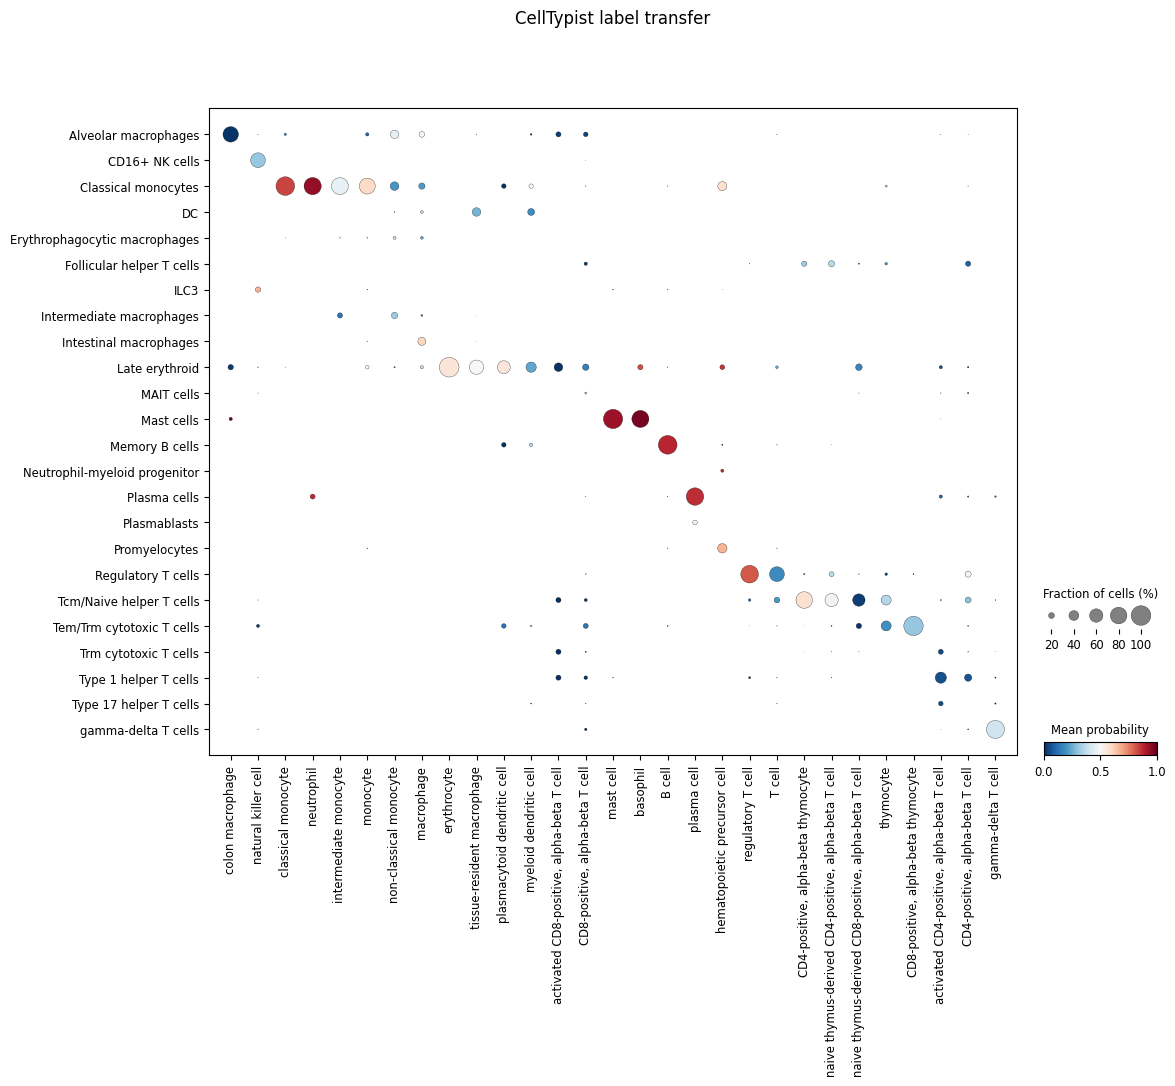

In [46]:
celltypist.dotplot(ct_predictions, use_as_reference = 'cell_type', use_as_prediction = 'majority_voting')

### Neighborhood graph, PCA

In [47]:
human1_ct.raw = human1_ct.copy()
sc.pp.highly_variable_genes(human1_ct)
sc.tl.pca(human1_ct, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(human1_ct)

In [48]:
np.mean(human1_ct.obs['majority_voting']==nearest_neighbor_cell_type(human1_ct,label_key='majority_voting'))

np.float64(0.8830182309250506)

In [52]:
np.mean(human1_ct.obs['predicted_labels']==nearest_neighbor_cell_type(human1_ct,label_key='predicted_labels'))

np.float64(0.5985820391627279)

In [50]:
np.mean(human1_ct.obs['cell_type']==nearest_neighbor_cell_type(human1_ct,label_key='cell_type'))

np.float64(0.7918636056718433)

~10% improvement in low-resolution cell type pairing using CellTypist vs Tabula Sapiens labels.

### PerturbOT with T cells all grouped together

In [56]:
t_mask = human1_ct.obs["majority_voting"].str.contains("T cells", na=False)

human1_ct.obs["voting_grouped_t"] = human1_ct.obs["majority_voting"].astype(str)
human1_ct.obs.loc[t_mask, "voting_grouped_t"] = "T cells"

In [68]:
human1a, human1b = split_adata_by_celltype_tissue(human1_ct, cell_type_key='voting_grouped_t')

In [69]:
# preprocessing for human 1a
sc.pp.highly_variable_genes(human1a)             # optional: select HVGs
human1a = human1a[:, human1a.var['highly_variable']].copy()  # optional
sc.pp.scale(human1a, max_value=10)               # z-score genes (recommended before PCA)
sc.tl.pca(human1a, n_comps=50)

In [70]:
# preprocessing for human 1b
sc.pp.highly_variable_genes(human1b)             # optional: select HVGs
human1b = human1b[:, human1b.var['highly_variable']].copy()  # optional
sc.pp.scale(human1b, max_value=10)               # z-score genes (recommended before PCA)
sc.tl.pca(human1b, n_comps=50)

In [72]:
human1a.obs['voting_no_t'].value_counts()

voting_no_t
T cells                          1368
Classical monocytes               483
Late erythroid                    391
Plasma cells                      165
DC                                 90
Promyelocytes                      78
Alveolar macrophages               67
Mast cells                         61
Memory B cells                     58
CD16+ NK cells                     50
Intermediate macrophages           26
Plasmablasts                       18
Neutrophil-myeloid progenitor      17
Intestinal macrophages             17
ILC3                               15
Erythrophagocytic macrophages       8
Name: count, dtype: int64

In [ ]:
human1a_X = human1a.obsm['X_pca']
human1b_X = human1b.obsm['X_pca']
human1a_labels = human1a.obs['voting_no_t'].tolist()
human1b_labels = human1b.obs['voting_no_t'].tolist()

In [73]:
def create_label_to_sample_dicts(a1, a2, celltype_key="shared_cell_type"):
    """
    Fast creation of per-cell-type dictionaries for two AnnData objects.

    Returns:
      X_dict, Y_dict: dict[int -> ndarray(shape=(n_cells, n_pcs))]
      X_full_dict, Y_full_dict: dict[int -> ndarray(shape=(n_cells, n_genes))]
      X_index_dict, Y_index_dict: dict[int -> pd.Index(of obs names)]
    """
    # 1) prepare cell-type categories (union to ensure consistent keys)
    ct1 = pd.Series(a1.obs[celltype_key].values, index=a1.obs.index)
    ct2 = pd.Series(a2.obs[celltype_key].values, index=a2.obs.index)
    ct_list = sorted(set(ct1.unique()).union(ct2.unique()))
    ct_keys = {ct: i for i, ct in enumerate(ct_list)}

    # 2) extract arrays once
    Xpca1 = np.asarray(a1.obsm['X_pca'])
    Xpca2 = np.asarray(a2.obsm['X_pca'])

    # full matrices: convert sparse to dense once (may be large)
    def to_dense(mat):
        if sparse.issparse(mat):
            return mat.toarray()
        return np.asarray(mat)

    Xfull1 = to_dense(a1.X)
    Xfull2 = to_dense(a2.X)

    # 3) group indices by cell type (vectorized)
    groups1 = ct1.groupby(ct1).groups  # {ct_value: Index([...obs_names...])}
    groups2 = ct2.groupby(ct2).groups

    # 4) build dicts (keys are integer labels from ct_keys)
    X_dict = {}
    Y_dict = {}
    X_full_dict = {}
    Y_full_dict = {}
    X_index_dict = {}
    Y_index_dict = {}

    for ct in ct_list:
        key = ct_keys[ct]

        # dataset 1
        ids1 = list(groups1.get(ct, []))  # obs index labels
        if ids1:
            pos1 = a1.obs.index.get_indexer(ids1)         # integer positions
            X_dict[key] = Xpca1[pos1].astype(np.float64)
            X_full_dict[key] = Xfull1[pos1].astype(np.float64)
            X_index_dict[key] = pd.Index(ids1)
        else:
            X_dict[key] = np.empty((0, Xpca1.shape[1]), dtype=np.float64)
            X_full_dict[key] = np.empty((0, Xfull1.shape[1]), dtype=np.float64)
            X_index_dict[key] = pd.Index([])

        # dataset 2
        ids2 = list(groups2.get(ct, []))
        if ids2:
            pos2 = a2.obs.index.get_indexer(ids2)
            Y_dict[key] = Xpca2[pos2].astype(np.float64)
            Y_full_dict[key] = Xfull2[pos2].astype(np.float64)
            Y_index_dict[key] = pd.Index(ids2)
        else:
            Y_dict[key] = np.empty((0, Xpca2.shape[1]), dtype=np.float64)
            Y_full_dict[key] = np.empty((0, Xfull2.shape[1]), dtype=np.float64)
            Y_index_dict[key] = pd.Index([])

    return X_dict, Y_dict, X_full_dict, Y_full_dict, X_index_dict, Y_index_dict

In [74]:
X_dict, Y_dict, X_full_dict, Y_full_dict, X_index_dict, Y_index_dict = create_label_to_sample_dicts(human1a, 
                                                                                                    human1b,
                                                                                                   celltype_key='voting_no_t')

In [130]:
T_dict, log = get_coupling_egw_labels_ott((X_dict, Y_dict), 1e-5)

running EGWL with ott
GW called
lse step
updating linearization
Label considered for Sinkhorn run
lse step
updating linearization
Label considered for Sinkhorn run
5 outer iterations were needed.
The last Sinkhorn iteration has converged: False
The outer loop of Gromov Wasserstein has converged: False
The final regularized GW cost is: -inf
Done running LEGWOT with ott


In [131]:
def combine_transport_plans(
    T_dict, source_index_dict, target_index_dict, source_adata, target_adata,
    *, key_order=None, return_dense=True,
    celltype_key="shared_cell_type", subtype_key="cell_type",
):
    keys = list(key_order) if key_order is not None else (sorted(T_dict) if all(isinstance(k, (int,float,str)) for k in T_dict) else list(T_dict))
    if set(keys) != set(T_dict) or set(T_dict) != set(source_index_dict) or set(T_dict) != set(target_index_dict):
        raise ValueError("Keys must match across T_dict/source_index_dict/target_index_dict (and key_order if provided).")

    blocks, src_ids, tgt_ids = [], [], []
    for k in keys:
        T = T_dict[k]
        r, c = T.shape
        s_ids, t_ids = list(source_index_dict[k]), list(target_index_dict[k])
        if len(s_ids) != r or len(t_ids) != c:
            raise ValueError(f"Shape/ID mismatch for key {k}: T is {T.shape}, len(src)={len(s_ids)}, len(tgt)={len(t_ids)}")
        blocks.append(T if sparse.issparse(T) else sparse.csr_matrix(np.asarray(T)))
        src_ids += s_ids; tgt_ids += t_ids

    T_big = sparse.block_diag(blocks, format="csr")
    if return_dense: T_big = T_big.toarray()

    def ann(adata, ids, side):
        obs = adata.obs.reindex(ids)
        if celltype_key not in obs or subtype_key not in obs:
            raise KeyError(f"{side}_adata.obs must contain '{celltype_key}' and '{subtype_key}'.")
        if obs[celltype_key].isna().any() or obs[subtype_key].isna().any():
            bad = obs.index[obs[celltype_key].isna() | obs[subtype_key].isna()]
            raise ValueError(f"{side}: {len(bad)} ids missing in obs index or annotations; e.g. {list(bad[:10])}")
        return obs[celltype_key].tolist(), obs[subtype_key].tolist()

    s_ct, s_st = ann(source_adata, src_ids, "source")
    t_ct, t_st = ann(target_adata, tgt_ids, "target")
    return T_big, s_ct, s_st, t_ct, t_st

In [132]:
T_full, human1a_ct, human1a_cst, human1b_ct, human1b_cst= combine_transport_plans(T_dict, 
                                                                                  X_index_dict,
                                                                                  Y_index_dict,
                                                                                  human1a,
                                                                                  human1b, 
                                                                                  celltype_key='majority_voting',
                                                                                  subtype_key='voting_no_t')

In [133]:
T_idx = 15
T_cell_coupling = T_dict[T_idx]
T_cell_X_index = X_index_dict[T_idx]
T_cell_Y_index = Y_index_dict[T_idx]

In [134]:
human1a_cst_t = human1a[T_cell_X_index].obs['majority_voting'].tolist()

In [135]:
human1b_cst_t = human1b[T_cell_Y_index].obs['majority_voting'].tolist()

In [136]:
pd.crosstab(
        human1a_cst_t,
        human1b_cst_t,
        dropna=False
    )

col_0,Follicular helper T cells,MAIT cells,Regulatory T cells,Tcm/Naive helper T cells,Tem/Trm cytotoxic T cells,Trm cytotoxic T cells,Type 1 helper T cells,Type 17 helper T cells,gamma-delta T cells
row_0,,,,,,,,,
Follicular helper T cells,19,0,23,81,13,0,0,0,0
MAIT cells,1,2,5,6,1,0,1,0,0
Regulatory T cells,24,3,155,46,18,1,8,5,13
Tcm/Naive helper T cells,74,3,56,288,45,3,5,0,1
Tem/Trm cytotoxic T cells,11,0,16,45,15,2,0,0,1
Trm cytotoxic T cells,0,0,2,4,1,2,16,7,1
Type 1 helper T cells,0,1,10,3,0,24,73,16,30
Type 17 helper T cells,0,0,4,0,0,5,12,4,5
gamma-delta T cells,0,1,17,5,0,2,28,3,102


In [137]:
compute_mapping_acc(T_cell_coupling, human1a_cst_t, human1b_cst_t)

0.7536549707602339

T cell subtype mapping accuracy is 75%.

In [128]:
# Exploring influence of entropy parameter
eps_arr = [1e-1, 1e-3, 1e-5, 1e-7]
acc_arr = []

for eps in eps_arr:
    T_dict, log = get_coupling_egw_labels_ott((X_dict, Y_dict), eps)
    T_cell_coupling = T_dict[T_idx]
    T_cell_X_index = X_index_dict[T_idx]
    T_cell_Y_index = Y_index_dict[T_idx]
    human1a_cst_t = human1a[T_cell_X_index].obs['majority_voting'].tolist()
    human1b_cst_t = human1b[T_cell_Y_index].obs['majority_voting'].tolist()
    acc = compute_mapping_acc(T_cell_coupling, human1a_cst_t, human1b_cst_t)
    print(eps, acc)
    acc_arr.append(acc)

running EGWL with ott
GW called
lse step
updating linearization
Label considered for Sinkhorn run
lse step
updating linearization
Label considered for Sinkhorn run
5 outer iterations were needed.
The last Sinkhorn iteration has converged: True
The outer loop of Gromov Wasserstein has converged: True
The final regularized GW cost is: 0.521
Done running LEGWOT with ott
0.1 0.3888888888888889
running EGWL with ott
GW called
lse step
updating linearization
Label considered for Sinkhorn run
lse step
updating linearization
Label considered for Sinkhorn run
5 outer iterations were needed.
The last Sinkhorn iteration has converged: True
The outer loop of Gromov Wasserstein has converged: True
The final regularized GW cost is: 0.341
Done running LEGWOT with ott
0.001 0.41812865497076024
running EGWL with ott
GW called
lse step
updating linearization
Label considered for Sinkhorn run
lse step
updating linearization
Label considered for Sinkhorn run
5 outer iterations were needed.
The last Sinkho

In [129]:
# Exploring influence of entropy parameter
eps_arr = [5e-5, 5e-6, 1e-8]
acc_arr = []

for eps in eps_arr:
    T_dict, log = get_coupling_egw_labels_ott((X_dict, Y_dict), eps)
    T_cell_coupling = T_dict[T_idx]
    T_cell_X_index = X_index_dict[T_idx]
    T_cell_Y_index = Y_index_dict[T_idx]
    human1a_cst_t = human1a[T_cell_X_index].obs['majority_voting'].tolist()
    human1b_cst_t = human1b[T_cell_Y_index].obs['majority_voting'].tolist()
    acc = compute_mapping_acc(T_cell_coupling, human1a_cst_t, human1b_cst_t)
    print(eps, acc)
    acc_arr.append(acc)

running EGWL with ott
GW called
lse step
updating linearization
Label considered for Sinkhorn run
lse step
updating linearization
Label considered for Sinkhorn run
5 outer iterations were needed.
The last Sinkhorn iteration has converged: False
The outer loop of Gromov Wasserstein has converged: False
The final regularized GW cost is: 0.344
Done running LEGWOT with ott
5e-05 0.6279239766081871
running EGWL with ott
GW called
lse step
updating linearization
Label considered for Sinkhorn run
lse step
updating linearization
Label considered for Sinkhorn run
7 outer iterations were needed.
The last Sinkhorn iteration has converged: False
The outer loop of Gromov Wasserstein has converged: False
The final regularized GW cost is: -inf
Done running LEGWOT with ott
5e-06 0.7529239766081871
running EGWL with ott
GW called
lse step
updating linearization
Label considered for Sinkhorn run
lse step
updating linearization
Label considered for Sinkhorn run
5 outer iterations were needed.
The last Si